# Full Feature Comparison Analysis

This notebook reads the current full-feature comparison artifacts and summarizes the tradeoff between predictive performance and theta recovery.


In [6]:
from pathlib import Path
import ast
import csv
import json
import math
import os
import statistics
import tempfile
from collections import defaultdict

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "briscola_mpl_cache"))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "artifacts" / "comparison").exists():
            return path
    raise FileNotFoundError("Could not find artifacts/comparison from current path")


ROOT = find_repo_root()
COMPARISON_DIR = ROOT / "artifacts" / "comparison"
SUMMARY_PATH = COMPARISON_DIR / "full_feature_comparison_summary.csv"
RUNS_PATH = COMPARISON_DIR / "full_feature_comparison_runs.csv"
REPORT_PATH = COMPARISON_DIR / "full_feature_comparison.json"

for path in (SUMMARY_PATH, RUNS_PATH, REPORT_PATH):
    if not path.exists():
        raise FileNotFoundError(path)


def read_csv(path):
    with path.open(newline="", encoding="utf-8") as handle:
        rows = list(csv.DictReader(handle))
    return [coerce_row(row) for row in rows]


def coerce_row(row):
    out = {}
    for key, value in row.items():
        if value is None:
            out[key] = value
            continue
        value = value.strip()
        if key in {"feature_set", "profile", "feature_names", "theta_true", "theta_posterior_mean", "theta_posterior_std", "theta_error", "heldout_likelihood"}:
            out[key] = value
        elif key in {"runs", "feature_count", "seed", "posterior_samples", "observations", "train_observations", "test_observations"}:
            out[key] = int(float(value))
        else:
            try:
                out[key] = float(value)
            except ValueError:
                out[key] = value
    return out


summary = read_csv(SUMMARY_PATH)
runs = read_csv(RUNS_PATH)
with REPORT_PATH.open(encoding="utf-8") as handle:
    report = json.load(handle)
config = report.get("config", {})

profiles = sorted({row["profile"] for row in summary})
feature_sets = sorted({row["feature_set"] for row in summary})

print("Loaded", len(summary), "summary rows and", len(runs), "run rows")
print("Config:")
for key in ["num_games", "train_fraction", "training_likelihood", "vi_steps", "prior_std", "elbo_samples", "posterior_samples", "seeds"]:
    print(f"  {key}: {config.get(key)}")


Loaded 6 summary rows and 18 run rows
Config:
  num_games: 100
  train_fraction: 0.75
  training_likelihood: sequential
  vi_steps: 200
  prior_std: 1.0
  elbo_samples: 2
  posterior_samples: 50
  seeds: [0, 1, 2]


## Performance Summary

The table below is sorted by held-out improvement. `prob_multiplier` is the geometric per-move probability improvement over the zero-theta baseline: `exp(heldout_mean_logp_delta_mean)`.


In [7]:
def fmt(value, digits=3):
    if isinstance(value, float):
        return f"{value:.{digits}f}"
    return str(value)


def make_markdown_table(rows, columns):
    header = "| " + " | ".join(label for label, _ in columns) + " |"
    sep = "| " + " | ".join("---" for _ in columns) + " |"
    body = []
    for row in rows:
        body.append("| " + " | ".join(formatter(row) for _, formatter in columns) + " |")
    return "\n".join([header, sep, *body])


def group_label(row):
    return f"{row['feature_set']} / {row['profile']}"


ranked = sorted(summary, key=lambda r: r["heldout_loglik_delta_mean"], reverse=True)
perf_rows = []
for row in ranked:
    multiplier = math.exp(row["heldout_mean_logp_delta_mean"])
    perf_rows.append({**row, "config": group_label(row), "prob_multiplier": multiplier})

columns = [
    ("rank", lambda r: str(perf_rows.index(r) + 1)),
    ("config", lambda r: r["config"]),
    ("theta L2 ↓", lambda r: fmt(r["theta_l2_error_mean"], 3)),
    ("heldout Δ ↑", lambda r: fmt(r["heldout_loglik_delta_mean"], 2)),
    ("mean logp Δ ↑", lambda r: fmt(r["heldout_mean_logp_delta_mean"], 4)),
    ("prob x ↑", lambda r: f"{r['prob_multiplier']:.3f}x"),
    ("ELBO ↑", lambda r: fmt(r["final_elbo_mean"], 1)),
    ("runs", lambda r: str(r["runs"])),
]

display(Markdown(make_markdown_table(perf_rows, columns)))


| rank | config | theta L2 ↓ | heldout Δ ↑ | mean logp Δ ↑ | prob x ↑ | ELBO ↑ | runs |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | core / conservative | 0.314 | 44.39 | 0.0888 | 1.093x | -3608.6 | 3 |
| 2 | interactive / greedy_points | 2.670 | 36.65 | 0.0733 | 1.076x | -3676.2 | 3 |
| 3 | core / aggressive | 0.314 | 31.79 | 0.0636 | 1.066x | -3654.5 | 3 |
| 4 | interactive / aggressive | 1.506 | 27.45 | 0.0549 | 1.056x | -3656.5 | 3 |
| 5 | interactive / conservative | 1.008 | 22.94 | 0.0459 | 1.047x | -3693.5 | 3 |
| 6 | core / greedy_points | 0.612 | 7.70 | 0.0154 | 1.016x | -3708.2 | 3 |

## Quick Read

This cell calls out the best configurations for each objective and the main tradeoff.


In [8]:
best_pred = max(summary, key=lambda r: r["heldout_loglik_delta_mean"])
best_recovery = min(summary, key=lambda r: r["theta_l2_error_mean"])
best_elbo = max(summary, key=lambda r: r["final_elbo_mean"])
worst_pred = min(summary, key=lambda r: r["heldout_loglik_delta_mean"])

lines = [
    f"**Best held-out prediction:** `{group_label(best_pred)}` with heldout Δ `{best_pred['heldout_loglik_delta_mean']:.2f}` and per-move multiplier `{math.exp(best_pred['heldout_mean_logp_delta_mean']):.3f}x`.",
    f"**Best theta recovery:** `{group_label(best_recovery)}` with theta L2 `{best_recovery['theta_l2_error_mean']:.3f}`.",
    f"**Best final ELBO:** `{group_label(best_elbo)}` with ELBO `{best_elbo['final_elbo_mean']:.1f}`.",
    f"**Weakest held-out prediction:** `{group_label(worst_pred)}` with heldout Δ `{worst_pred['heldout_loglik_delta_mean']:.2f}`.",
]

display(Markdown("\n\n".join(lines)))


**Best held-out prediction:** `core / conservative` with heldout Δ `44.39` and per-move multiplier `1.093x`.

**Best theta recovery:** `core / aggressive` with theta L2 `0.314`.

**Best final ELBO:** `core / conservative` with ELBO `-3608.6`.

**Weakest held-out prediction:** `core / greedy_points` with heldout Δ `7.70`.

## Core vs Interactive by Profile

These paired comparisons make it clear when the richer `interactive` feature set helps prediction and when it hurts interpretability.


In [9]:
summary_by_key = {(row["feature_set"], row["profile"]): row for row in summary}
comparison_rows = []
for profile in profiles:
    core = summary_by_key.get(("core", profile))
    interactive = summary_by_key.get(("interactive", profile))
    if not core or not interactive:
        continue
    comparison_rows.append({
        "profile": profile,
        "theta_core": core["theta_l2_error_mean"],
        "theta_interactive": interactive["theta_l2_error_mean"],
        "heldout_core": core["heldout_loglik_delta_mean"],
        "heldout_interactive": interactive["heldout_loglik_delta_mean"],
        "heldout_diff_core_minus_interactive": core["heldout_loglik_delta_mean"] - interactive["heldout_loglik_delta_mean"],
        "theta_diff_core_minus_interactive": core["theta_l2_error_mean"] - interactive["theta_l2_error_mean"],
    })

columns = [
    ("profile", lambda r: r["profile"]),
    ("theta L2 core", lambda r: fmt(r["theta_core"], 3)),
    ("theta L2 interactive", lambda r: fmt(r["theta_interactive"], 3)),
    ("heldout core", lambda r: fmt(r["heldout_core"], 2)),
    ("heldout interactive", lambda r: fmt(r["heldout_interactive"], 2)),
    ("heldout core - interactive", lambda r: f"{r['heldout_diff_core_minus_interactive']:+.2f}"),
]

display(Markdown(make_markdown_table(comparison_rows, columns)))


| profile | theta L2 core | theta L2 interactive | heldout core | heldout interactive | heldout core - interactive |
| --- | --- | --- | --- | --- | --- |
| aggressive | 0.314 | 1.506 | 31.79 | 27.45 | +4.34 |
| conservative | 0.314 | 1.008 | 44.39 | 22.94 | +21.45 |
| greedy_points | 0.612 | 2.670 | 7.70 | 36.65 | -28.95 |

## Main Performance Charts

- Left: held-out predictive improvement versus the zero-theta baseline.
- Right: theta recovery error. Lower is better.

Error bars are the standard deviation across the 3 seeds.


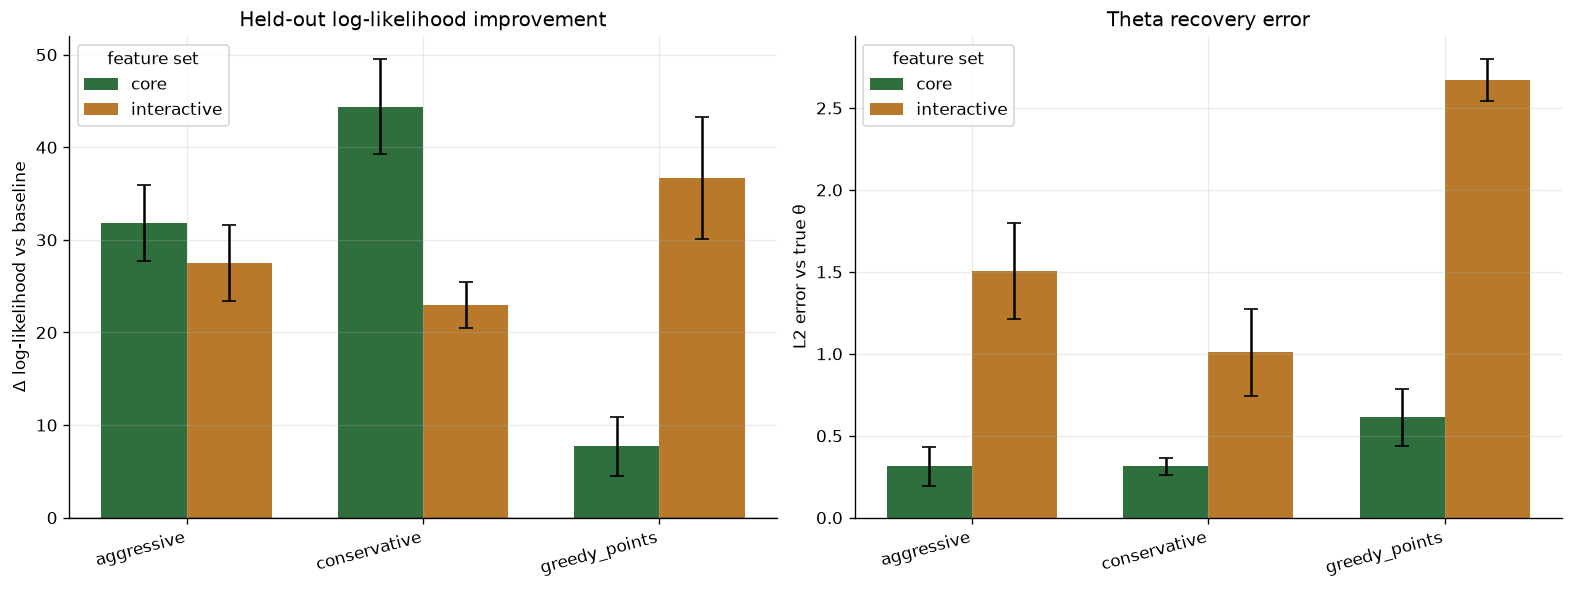

In [10]:
colors = {"core": "#2f6f3e", "interactive": "#b8792b"}
profile_order = ["aggressive", "conservative", "greedy_points"]
feature_order = ["core", "interactive"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
width = 0.36
x = np.arange(len(profile_order))

for i, feature_set in enumerate(feature_order):
    offsets = x + (i - 0.5) * width
    rows = [summary_by_key[(feature_set, profile)] for profile in profile_order]
    heldout = [row["heldout_loglik_delta_mean"] for row in rows]
    heldout_std = [row["heldout_loglik_delta_std"] for row in rows]
    theta = [row["theta_l2_error_mean"] for row in rows]
    theta_std = [row["theta_l2_error_std"] for row in rows]

    axes[0].bar(offsets, heldout, width, yerr=heldout_std, capsize=4, label=feature_set, color=colors[feature_set])
    axes[1].bar(offsets, theta, width, yerr=theta_std, capsize=4, label=feature_set, color=colors[feature_set])

axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Held-out log-likelihood improvement")
axes[0].set_ylabel("Δ log-likelihood vs baseline")
axes[0].set_xticks(x)
axes[0].set_xticklabels(profile_order, rotation=15, ha="right")
axes[0].legend(title="feature set")

axes[1].set_title("Theta recovery error")
axes[1].set_ylabel("L2 error vs true θ")
axes[1].set_xticks(x)
axes[1].set_xticklabels(profile_order, rotation=15, ha="right")
axes[1].legend(title="feature set")

plt.show()


## Prediction vs Interpretability Tradeoff

Good configurations should move toward the upper-left: high held-out improvement and low theta recovery error.


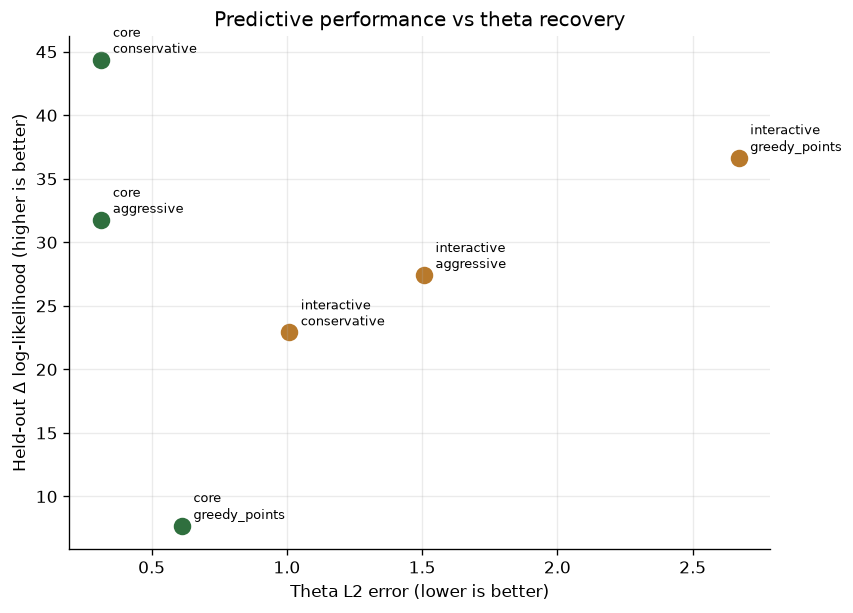

In [11]:
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

for row in summary:
    color = colors.get(row["feature_set"], "#555555")
    ax.scatter(row["theta_l2_error_mean"], row["heldout_loglik_delta_mean"], s=90, color=color)
    ax.annotate(
        f"{row['feature_set']}\n{row['profile']}",
        (row["theta_l2_error_mean"], row["heldout_loglik_delta_mean"]),
        textcoords="offset points",
        xytext=(7, 4),
        fontsize=8,
    )

ax.set_title("Predictive performance vs theta recovery")
ax.set_xlabel("Theta L2 error (lower is better)")
ax.set_ylabel("Held-out Δ log-likelihood (higher is better)")
plt.show()


## True vs Posterior Mean for Each Configuration

This gives the most direct diagnostic: when bars differ strongly, the model predicts with weights that do not match the synthetic ground truth.


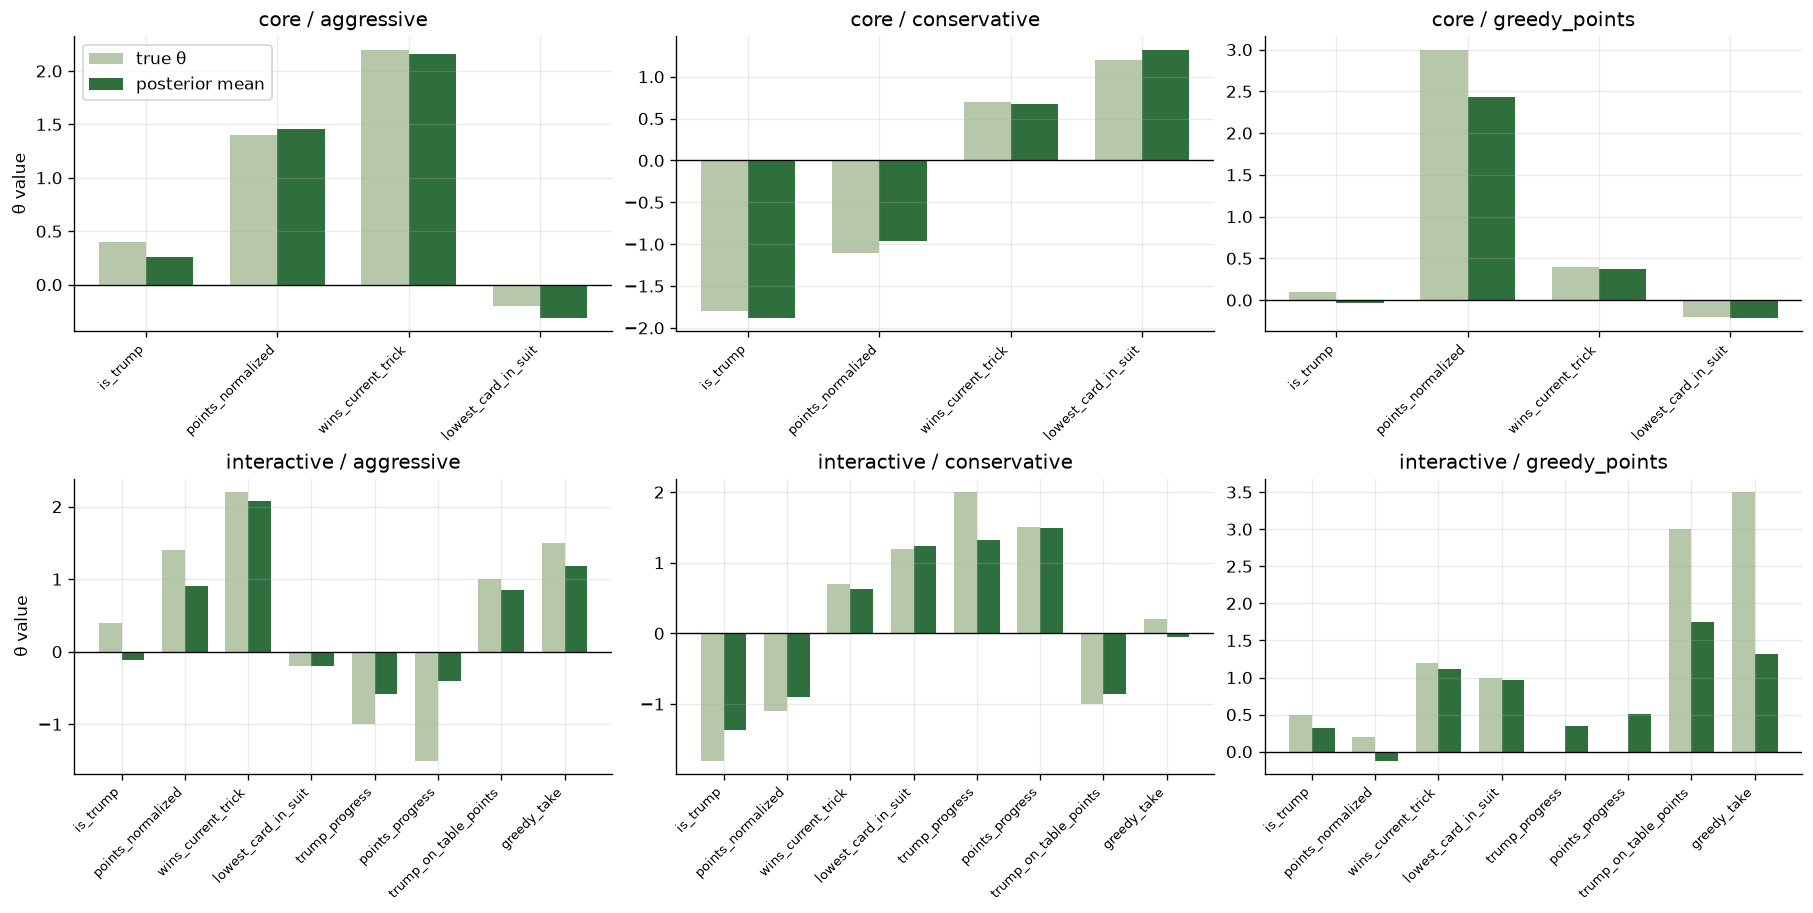

In [14]:
def mean_vector(selected_rows, key):
    vectors = [ast.literal_eval(row[key]) for row in selected_rows]
    return [statistics.fmean(vector[i] for vector in vectors) for i in range(len(vectors[0]))]

fig, axes = plt.subplots(len(feature_order), len(profile_order), figsize=(15, 7.5), constrained_layout=True)

for row_i, feature_set in enumerate(feature_order):
    for col_i, profile in enumerate(profile_order):
        ax = axes[row_i][col_i]
        selected = [row for row in runs if row["feature_set"] == feature_set and row["profile"] == profile]
        names = ast.literal_eval(selected[0]["feature_names"])
        true_theta = ast.literal_eval(selected[0]["theta_true"])
        posterior_mean = mean_vector(selected, "theta_posterior_mean")
        x = np.arange(len(names))
        ax.bar(x - 0.18, true_theta, width=0.36, label="true θ", color="#b6c8a9")
        ax.bar(x + 0.18, posterior_mean, width=0.36, label="posterior mean", color="#2f6f3e")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(f"{feature_set} / {profile}")
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
        if col_i == 0:
            ax.set_ylabel("θ value")
        if row_i == 0 and col_i == 0:
            ax.legend()

plt.show()
